dataset link - "https://drive.google.com/file/d/14HxGsihuTglSbjmhCMANv5f9o6SKR5OC/view"

employee attrition - possibility of employee resigning, employee who are leaving the company

# Problem Statement

1. Acomapany is facing the issue of employee attrition which is affection their business, deadlines are being delayed, projects stay imcomplete due to lack of expertise and experience.

2. So they have asked an analyst to find out what are the different reasons due to which the employees are resigning.

3. So the HR has surveyed the different employees from various departments and has provided a set of data.

-- **We as the analyst have to use this data to find out the various possible reasons due to which the employees are resigning and provide the inference to the HR**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/employe (2).csv")

In [ ]:
# print 10 random rows from the data

df.sample(10)

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
2642,0.93,0.74,4,201,3,1,0,0,IT,medium
6518,0.63,0.78,2,158,5,1,0,0,sales,medium
2955,0.55,0.65,4,170,4,0,0,0,sales,low
8155,0.36,0.48,2,137,3,0,1,0,technical,low
1097,0.11,0.86,6,254,4,0,1,0,sales,medium
10420,0.49,0.99,3,221,2,1,0,0,technical,medium
12214,0.40,0.79,5,181,5,0,0,0,IT,medium
150,0.44,0.54,2,149,3,0,1,0,hr,low
778,0.82,0.82,4,249,5,0,1,0,hr,low
7824,0.77,0.82,3,153,3,1,0,0,technical,medium


In [ ]:
# print basis info about data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
# print the names of all the columns
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

In [ ]:
# 1. satisfactoryLevel - how much the employees are satisfied in the company
#                     - ratings are on a scale of 0-1
# possibility - if the satisfactory level is low the attrition chances would be high


# 2. lastEvaluation - last performance score , range 0-1
# possibility - people with less evaluation will leave or even if people r having high evaluation but no salary hike

# 3. numberOfProjects - how many number of projects the person is working upon
# possibility - either too less projects or too many projects can trigger the attrition
# people with more projects will leave due to workload
# people with less projects they might feel undervalued and feel their skills are not being utilised and respected so they might leave -- they might feel they are not getting a chance to grow.

# 4. avgMonthlyHours - how much time on an average they are working
# possibility - more working hrs = more work load
# if the work hours are less they might not be interested in the work or maybe overstressed so they might also leave

# 5. timeSpent.company -- tenure, from how many years the employee is in the company
# possibility -- more years with the company with no promotion and increment will leave,
# if they have spent way too many years in the company they start to get comfortable and do not leave
# if the people are freshers they might also think of staying in the company to gain some experience
# if the people have been there in the company for an average years they might think of leaving for better oppurtunities

# 6. workAccident - any accident that would have occured during the work hours
# only two values - 0 and 1
# 0 - false - no
# 1 - true - yes

# if the value is 1 there's a high chance the employee will leave the company

# 8.promotionInLast5years -- if they have got any promotion in the previous 5 years
# if there is no promotion of employees they will see no growth and eventually they will leave and if they have been promoted they will stay


# 9. dept -- various departments from where the data is completion_is_selected

# 10. salary -- the different salary levels the employees are getting is mentioned.
# possibility - people who are getting low or high salary might have a tendency to leave.


In [ ]:
# The different values inside the number of project col

df['numberOfProjects'].unique()

array([2, 5, 7, 6, 4, 3])

In [ ]:
df['numberOfProjects'].value_counts() # along with the unique values we
# we also get the count that how many people are working on how many projects

,count
numberOfProjects,
4,4365
3,4055
5,2761
2,2388
6,1174
7,256


In [ ]:
df['workAccident'].unique()

array([0, 1])

In [ ]:
df['promotionInLast5years'].unique()

array([0, 1])

In [ ]:
df['dept'].value_counts()

,count
dept,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


In [ ]:
df['salary'].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


## Target column - left

In [ ]:
df['left'].unique()

array([1, 0])

In [ ]:
# 1 - true --> the employee has left the company
# 0 - false --> the employee is staying in the company

# Clean the dataset

In [ ]:
# check the null values in the data

df.isnull().sum()

,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


In [ ]:
df.duplicated().sum()

np.int64(3008)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(11991, 10)

# Analysis with Visualisation

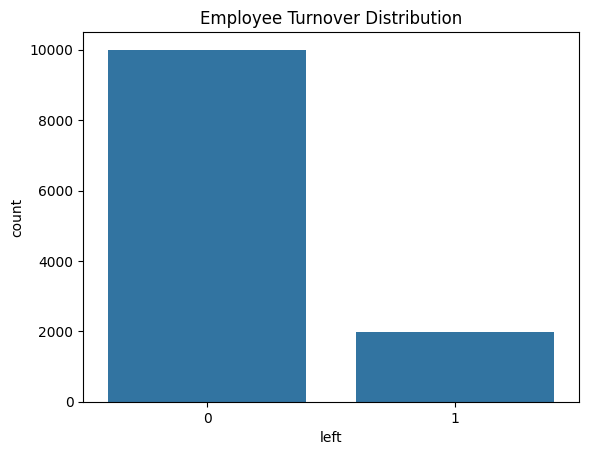

In [ ]:
# Create a chart to show the distribution of employee turnover

sns.countplot(x='left', data=df)
plt.title("Employee Turnover Distribution")
plt.show()

In [ ]:
# histogram and countplot -- both are frequency charts
# histogram is used when we have numerical data
# countplot is used when we have categorical data

In [ ]:
# 1. trend analysis -- analysis over a period of time -- lineplot
# 2. compare categorical and numerical things -- bar chart
# 3. compare the proportions -- pie chart
# 4. compare two or more numerical variables -- scatter plot
# 5. compare all the numerical cols in dataset with each other -- pairwise comparison -- sns.pairplot
# 6. correlation between different cols -- heatmap
# 7. histogram and kde plots -- distribution of the data
# 8. outliers -- boxplot, violinplot

plotly - 3d charts library

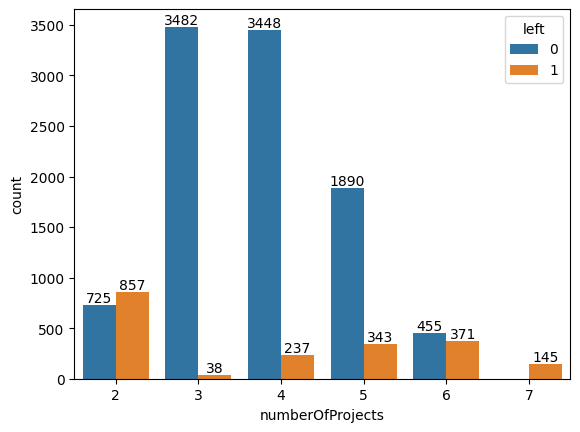

In [ ]:
# affect of number of projects on employee attrition

x1 = sns.countplot(x='numberOfProjects', data = df, hue = 'left')
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])
plt.show()

- 2 projects
Employees may feel underutilized or bored.
This can increase attrition.
- 3–5 projects
Employees are properly engaged.
Usually the lowest attrition rate occurs here.
- 6–7+ projects
Employees may experience work overload or stress.
This can increase attrition again

Find out the relationship between promotion and employee turnover.

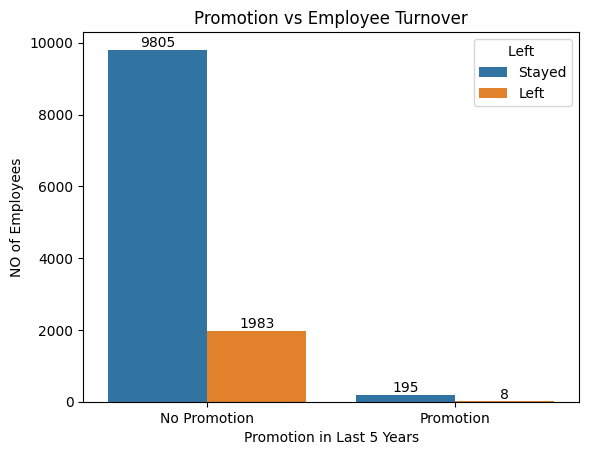

In [ ]:
# 21:19

x1 = sns.countplot(x='promotionInLast5years', hue='left', data=df)
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])
plt.xlabel("Promotion in Last 5 Years")
plt.ylabel("NO of Employees")
plt.title("Promotion vs Employee Turnover")
plt.xticks([0,1], ["No Promotion", "Promotion"])
plt.legend(title="Left ", labels=["Stayed", "Left"])
plt.show()

In [ ]:
# 21:25

Find out the relationship of the tenure and employee turnover

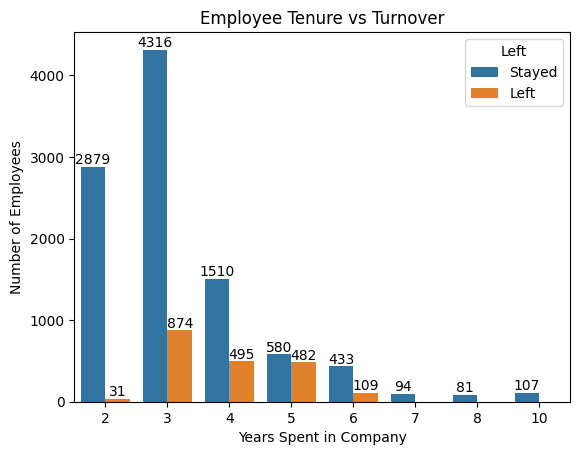

In [ ]:
x1 = sns.countplot(x="timeSpent.company", hue="left", data=df)
x1.bar_label(x1.containers[0])
x1.bar_label(x1.containers[1])

plt.title("Employee Tenure vs Turnover")
plt.xlabel("Years Spent in Company")
plt.ylabel("Number of Employees")

plt.legend(title="Left", labels=["Stayed", "Left"])

plt.show()

## filter the employees who got promotion but left

In [ ]:
df1 = df[(df['promotionInLast5years']==1)&(df['left']==1)]

In [ ]:
df1

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
52,0.79,0.59,4,139,3,0,1,1,management,low
189,0.11,0.79,6,292,4,0,1,1,technical,low
386,0.41,0.56,2,154,3,0,1,1,support,medium
1131,0.44,0.55,2,128,3,0,1,1,IT,medium
7980,0.45,0.51,2,160,3,1,1,1,sales,low
8085,0.41,0.46,2,160,3,0,1,1,sales,low
8469,0.46,0.45,2,138,3,0,1,1,IT,low
14530,0.87,1.00,4,258,5,1,1,1,sales,medium


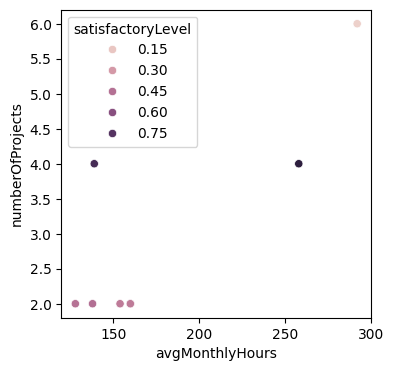

In [ ]:
# Create a scatter plot which shows the satisfactory level, no of projects, avgMonthlyHours

# 22:11

plt.figure(figsize=(4,4))
sns.scatterplot(x='avgMonthlyHours',y='numberOfProjects',data=df1,hue='satisfactoryLevel')
plt.show()

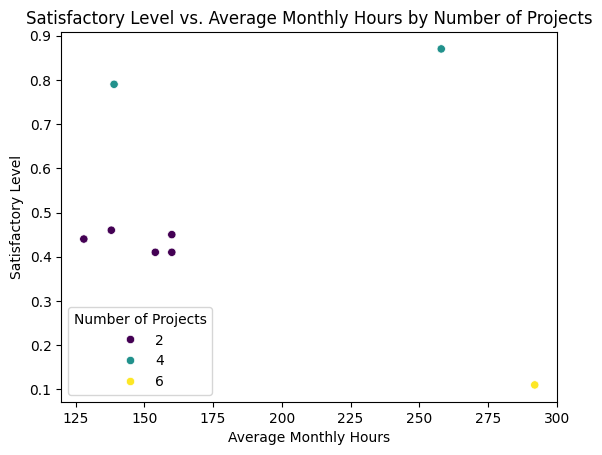

In [ ]:
sns.scatterplot(x='avgMonthlyHours', y='satisfactoryLevel', hue='numberOfProjects', data=df1, palette='viridis')
plt.title('Satisfactory Level vs. Average Monthly Hours by Number of Projects')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Satisfactory Level')
plt.legend(title='Number of Projects')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
sales = [200, 250, 300, 280, 350]
profit = [20, 25, 35, 30, 45]

# Create figure and first axis
fig, ax1 = plt.subplots()

# First graph (Left Y-axis)
ax1.plot(months, sales, marker='o', label='Sales')
ax1.set_ylabel('Sales')

# Create second Y-axis
ax2 = ax1.twinx()

# Second graph (Right Y-axis)
ax2.plot(months, profit, marker='s', linestyle='--', label='Profit')
ax2.set_ylabel('Profit')

# Title
plt.title('Sales vs Profit')

# Show plot
plt.show()

In [ ]:
fig, ax1 = plt.subplots()

ax1.bar(x, sales)

ax2 = ax1.twinx()
ax2.plot(x, profit)

NameError: name 'plt' is not defined